In [1]:
from google.colab.output import eval_js
print(eval_js("google.colab.kernel.proxyPort(5000)"))

https://5000-m-s-2vtfa4veid53c-b.europe-west4-0.prod.colab.dev


In [14]:
# إغلاق الأنفاق القديمة (إذا كانت موجودة)
ngrok.kill()

# إعادة تشغيل نفق جديد باستخدام التوكن الحالي
ngrok.set_auth_token("2wRJFhEYN0MU6JXwW80jLB54M0n_mtr2ZeZBAT7ixgZ88Cye")  # تأكد من التوكن الصحيح
public_url = ngrok.connect(5000)
print(f' * Ngrok Tunnel: {public_url}')
############################################################ تشغلها اذا ثلك autkon ممتلئ فقط

 * Ngrok Tunnel: NgrokTunnel: "https://210c-34-30-123-25.ngrok-free.app" -> "http://localhost:5000"


In [6]:
!pip install pyngrok
from pyngrok import ngrok

# استبدل "your_authtoken" بـ authtoken الخاص بك الذي حصلت عليه من حساب ngrok
ngrok.set_auth_token("2wRJFhEYN0MU6JXwW80jLB54M0n_mtr2ZeZBAT7ixgZ88Cye")

# تشغيل نفق على المنفذ 5000
public_url = ngrok.connect(5000)
print(f' * ngrok tunnel "http://127.0.0.1:5000" -> "{public_url}"')
# تحملها لحالها
###############################################################


 * ngrok tunnel "http://127.0.0.1:5000" -> "NgrokTunnel: "https://5b17-34-90-221-251.ngrok-free.app" -> "http://localhost:5000""


https://5000-m-s-2vtfa4veid53c-b.europe-west4-0.prod.colab.dev
 * Ngrok Tunnel: NgrokTunnel: "https://20fb-34-90-221-251.ngrok-free.app" -> "http://localhost:5000"
True Accuracy: 66.67 %
Predictions: [1, 0, 0]
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [30/Apr/2025 13:55:26] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [30/Apr/2025 13:55:26] "GET /favicon.ico HTTP/1.1" 404 -


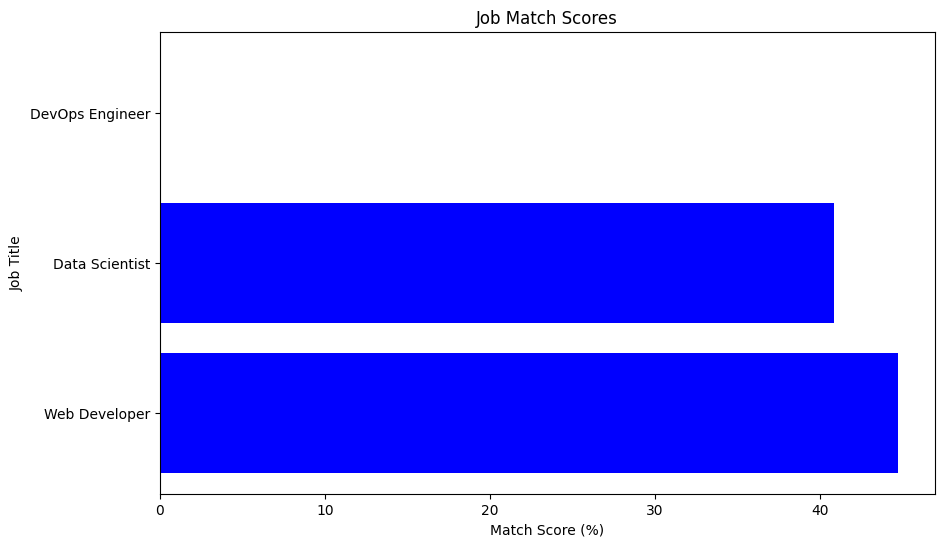

INFO:werkzeug:127.0.0.1 - - [30/Apr/2025 13:55:29] "POST / HTTP/1.1" 200 -


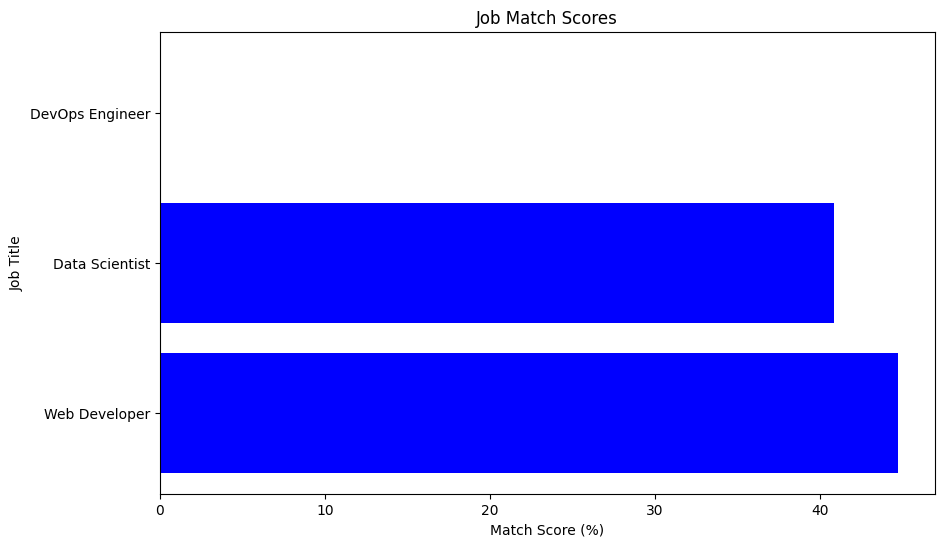

INFO:werkzeug:127.0.0.1 - - [30/Apr/2025 13:55:54] "POST / HTTP/1.1" 200 -


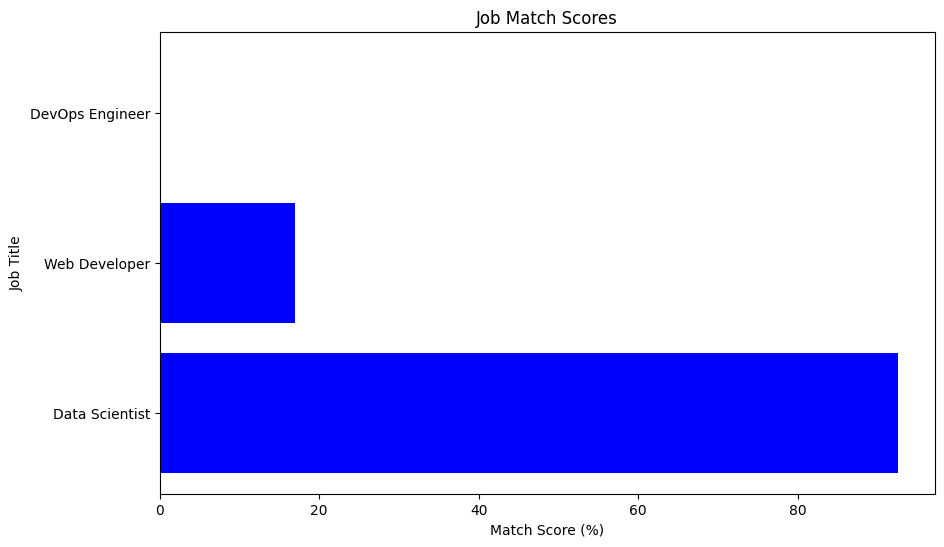

INFO:werkzeug:127.0.0.1 - - [30/Apr/2025 13:56:15] "POST / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [30/Apr/2025 17:32:06] "GET / HTTP/1.1" 200 -


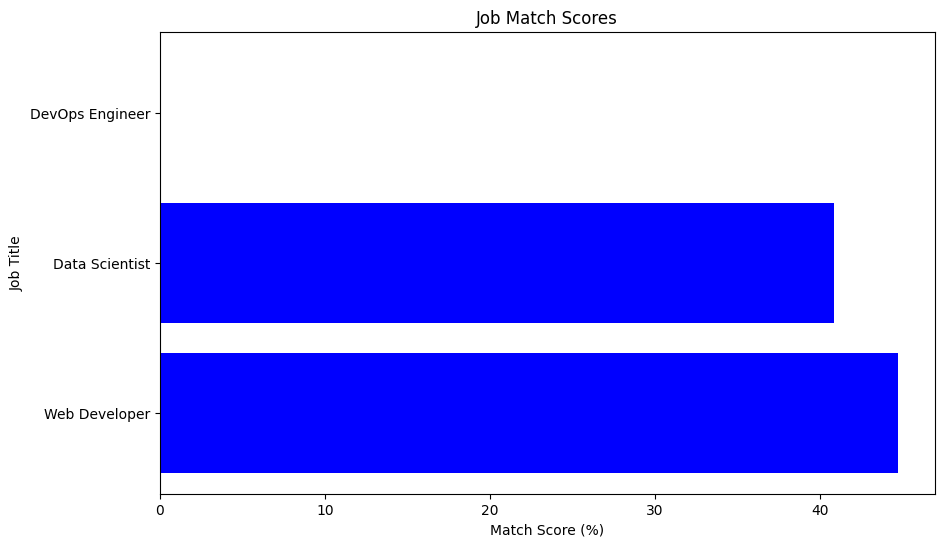

INFO:werkzeug:127.0.0.1 - - [30/Apr/2025 17:32:11] "POST / HTTP/1.1" 200 -


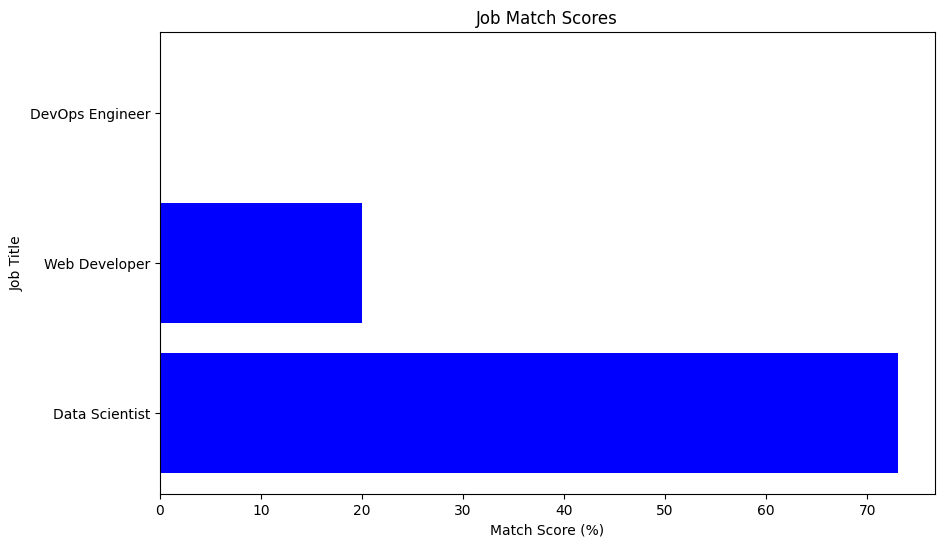

INFO:werkzeug:127.0.0.1 - - [30/Apr/2025 17:32:17] "POST / HTTP/1.1" 200 -


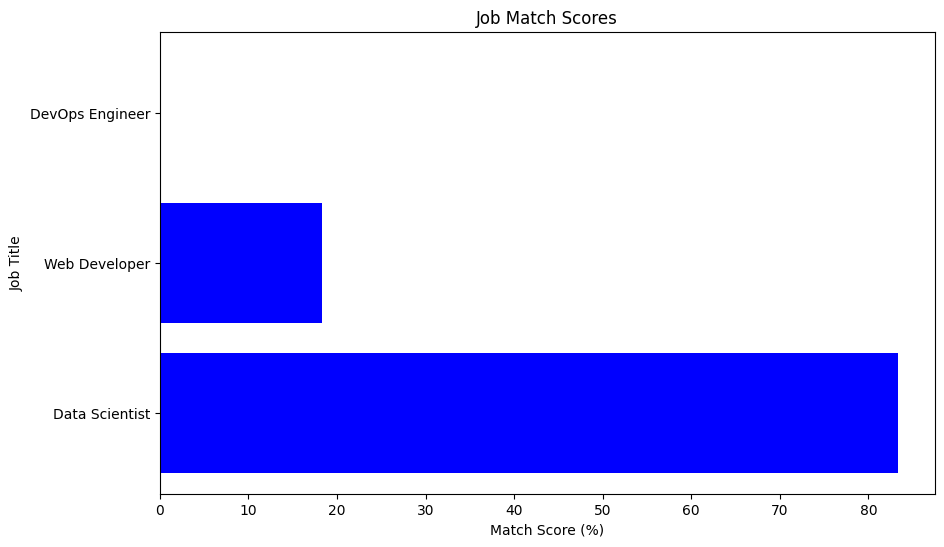

INFO:werkzeug:127.0.0.1 - - [30/Apr/2025 17:32:23] "POST / HTTP/1.1" 200 -


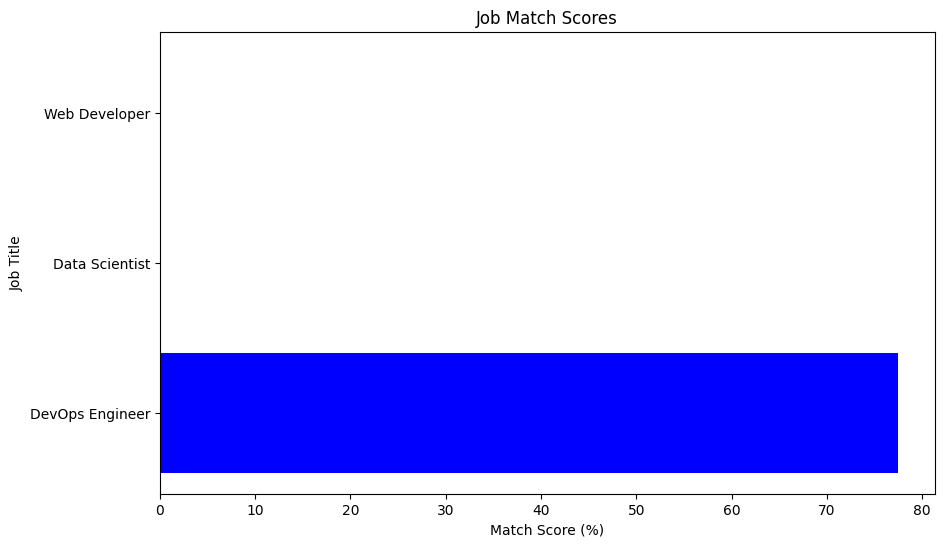

INFO:werkzeug:127.0.0.1 - - [30/Apr/2025 17:32:29] "POST / HTTP/1.1" 200 -


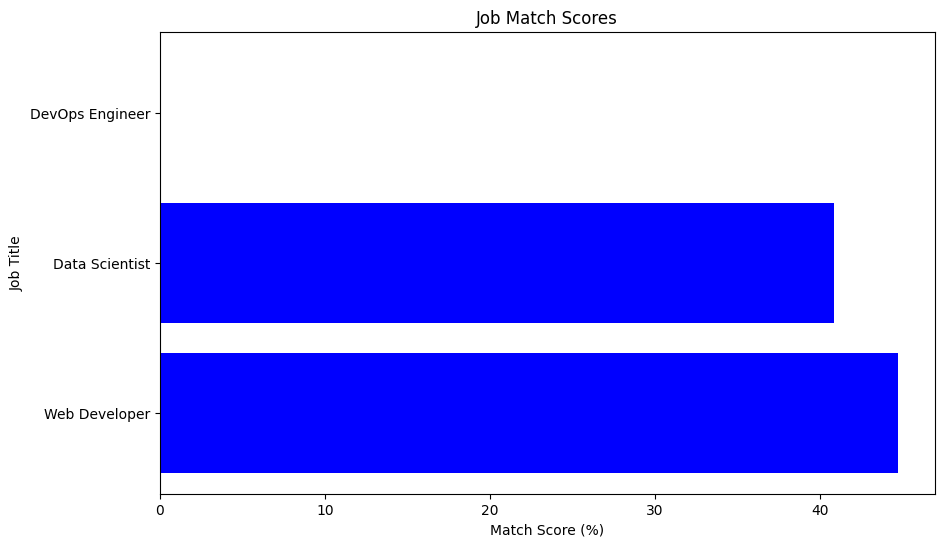

INFO:werkzeug:127.0.0.1 - - [30/Apr/2025 17:32:33] "POST / HTTP/1.1" 200 -


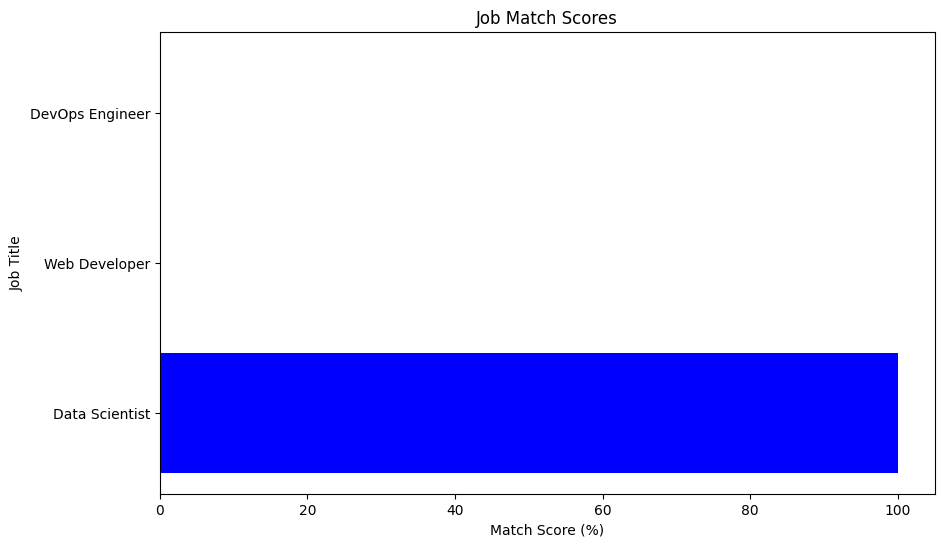

INFO:werkzeug:127.0.0.1 - - [30/Apr/2025 17:32:39] "POST / HTTP/1.1" 200 -


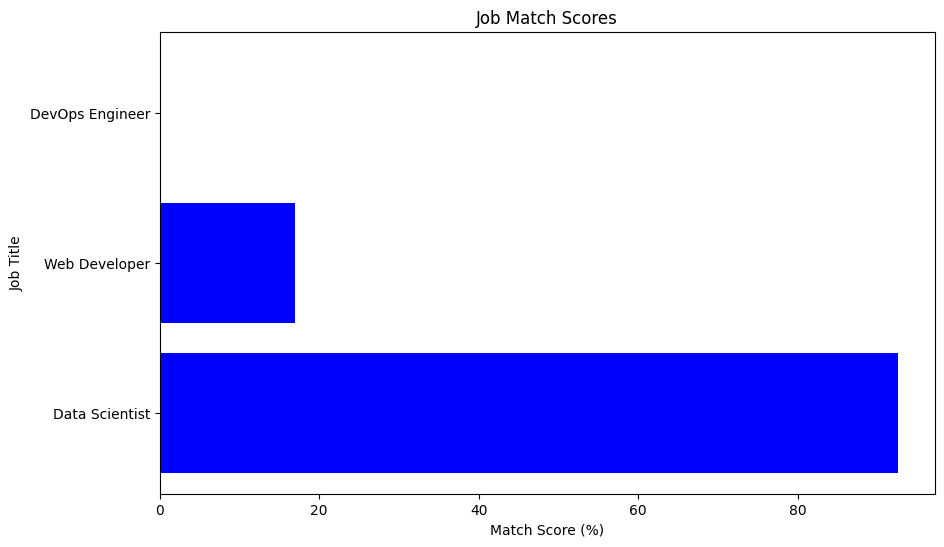

INFO:werkzeug:127.0.0.1 - - [30/Apr/2025 17:32:43] "POST / HTTP/1.1" 200 -


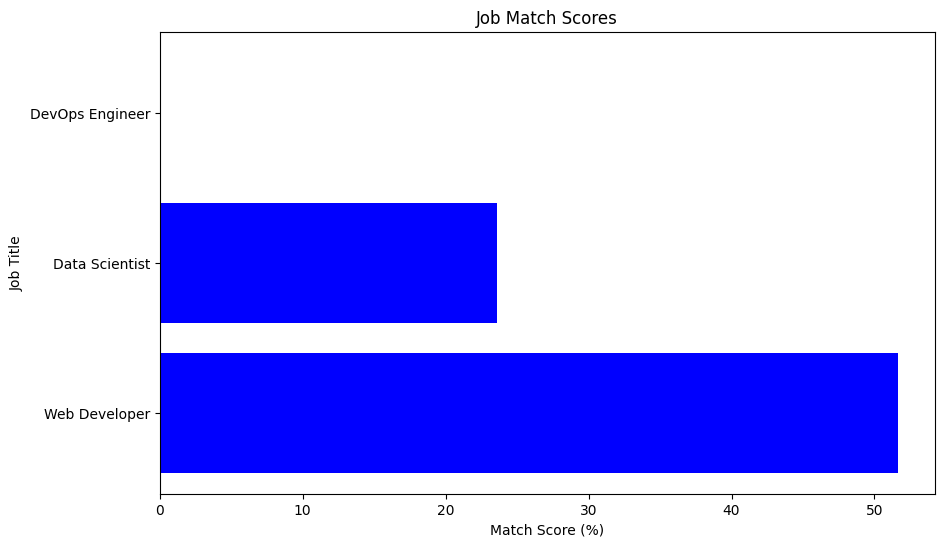

INFO:werkzeug:127.0.0.1 - - [30/Apr/2025 17:32:47] "POST / HTTP/1.1" 200 -


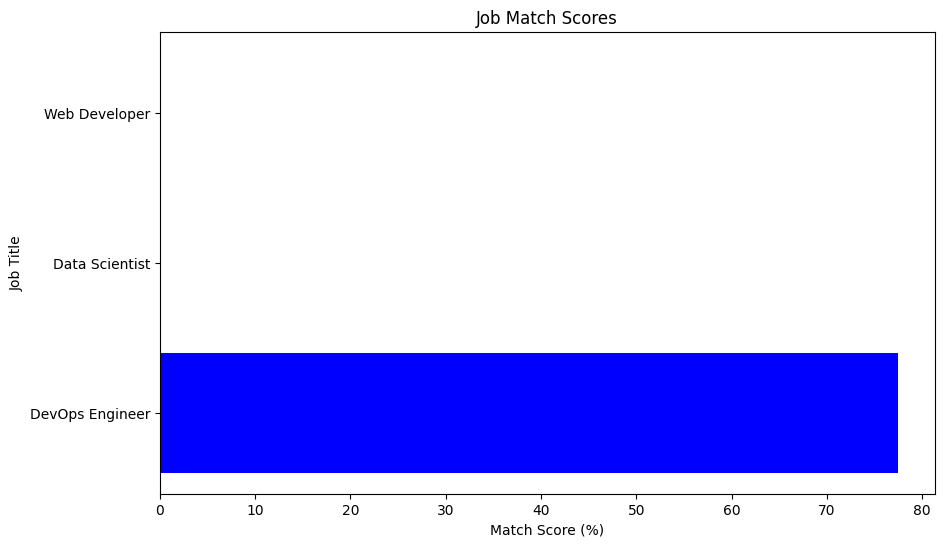

INFO:werkzeug:127.0.0.1 - - [30/Apr/2025 17:32:52] "POST / HTTP/1.1" 200 -


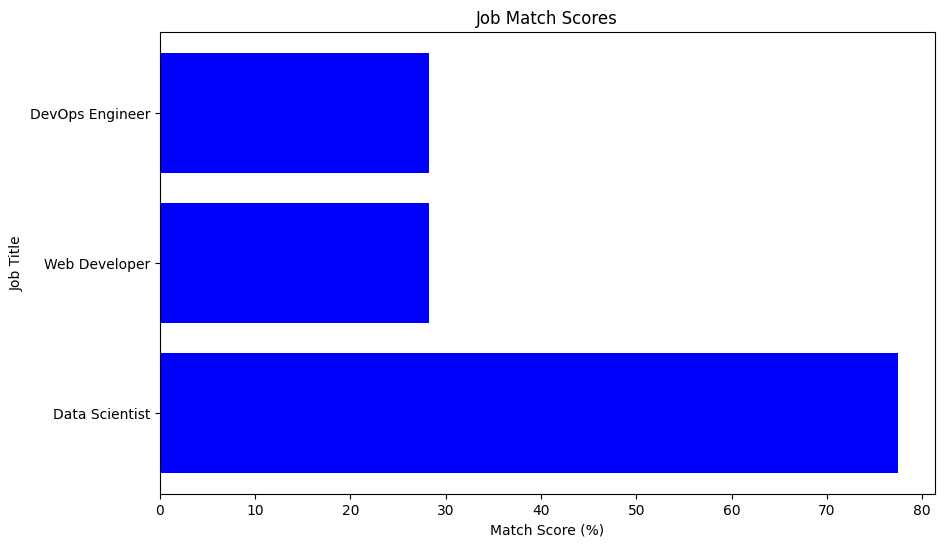

INFO:werkzeug:127.0.0.1 - - [30/Apr/2025 17:32:59] "POST / HTTP/1.1" 200 -


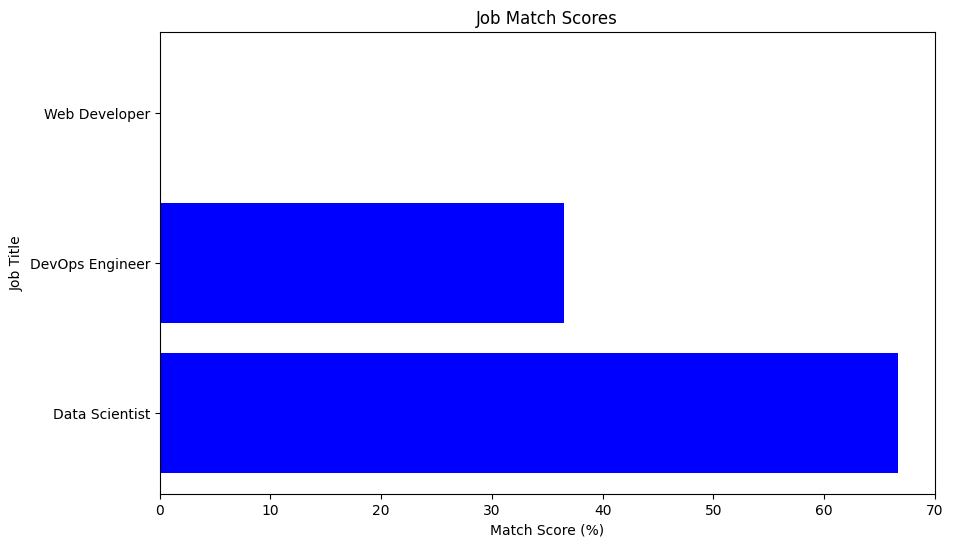

INFO:werkzeug:127.0.0.1 - - [30/Apr/2025 17:33:08] "POST / HTTP/1.1" 200 -


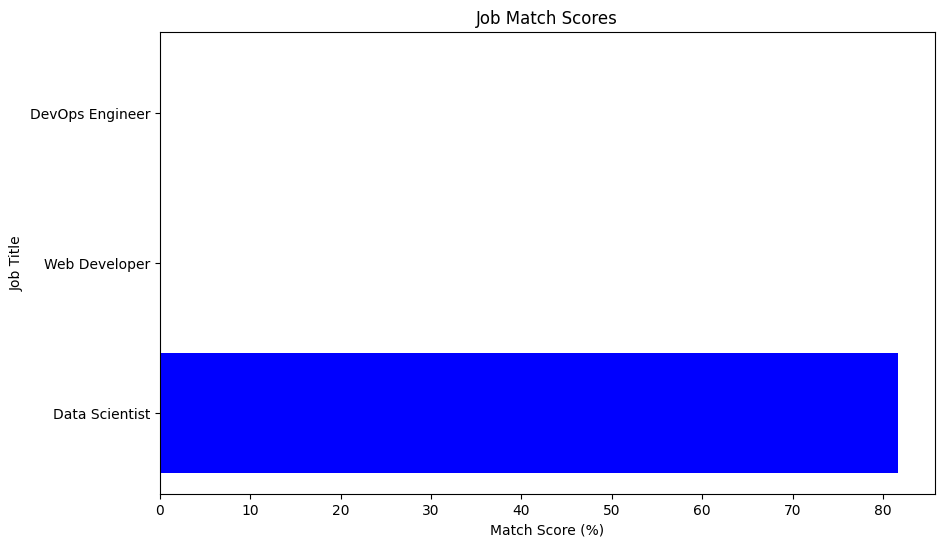

INFO:werkzeug:127.0.0.1 - - [30/Apr/2025 17:33:12] "POST / HTTP/1.1" 200 -


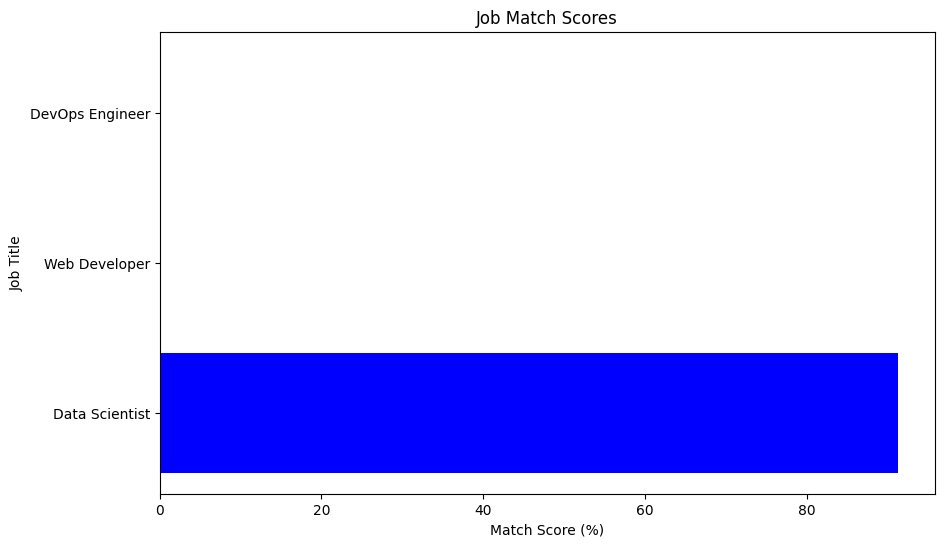

INFO:werkzeug:127.0.0.1 - - [30/Apr/2025 17:33:18] "POST / HTTP/1.1" 200 -


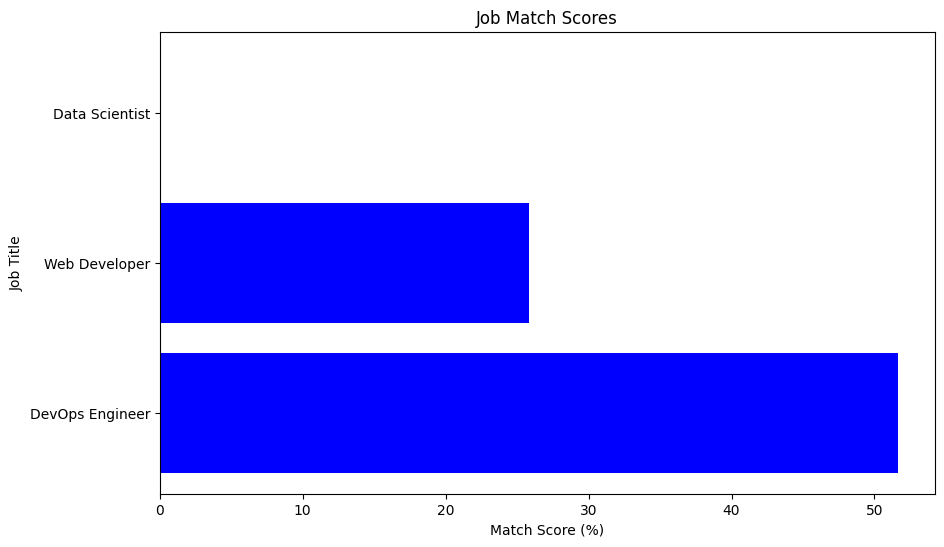

INFO:werkzeug:127.0.0.1 - - [30/Apr/2025 17:33:24] "POST / HTTP/1.1" 200 -


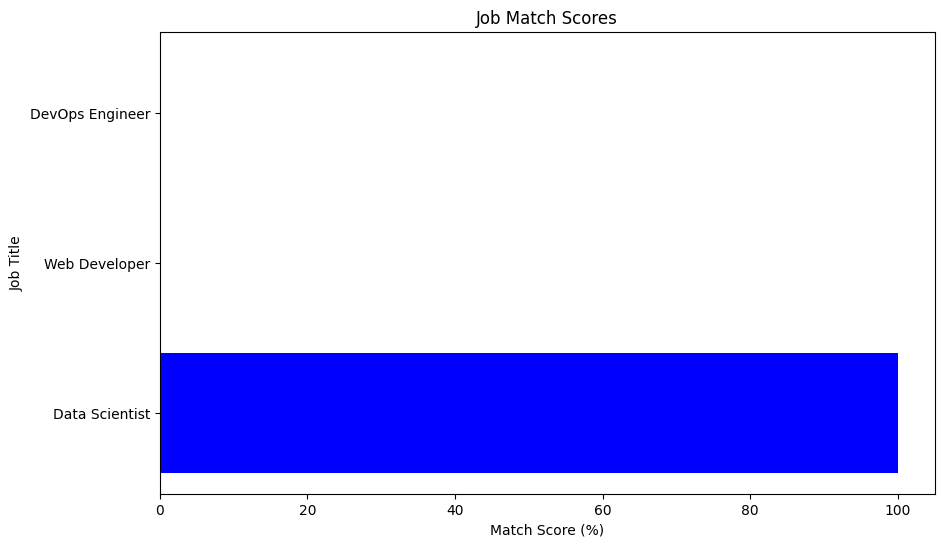

INFO:werkzeug:127.0.0.1 - - [30/Apr/2025 17:33:28] "POST / HTTP/1.1" 200 -


In [ ]:
!pip install flask pyngrok python-docx PyPDF2 flask-cors
!pip install matplotlib

import csv
from flask import Flask, render_template_string, request
from pyngrok import ngrok
import re
import tempfile
import PyPDF2
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import docx
from docx import Document
from flask_cors import CORS
import random
import os
from google.colab.output import eval_js
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import io
import base64


# رابط التطبيق
print(eval_js("google.colab.kernel.proxyPort(5000)"))

# إغلاق الأنفاق القديمة إذا كانت موجودة
ngrok.kill()

# ngrok إعداد التوكن الجديد
ngrok.set_auth_token("2wRJFhEYN0MU6JXwW80jLB54M0n_mtr2ZeZBAT7ixgZ88Cye")  # تأكد من التوكن الصحيح
public_url = ngrok.connect(5000)
print(f' * Ngrok Tunnel: {public_url}')

# واجهة الموقع HTML (مضمنة داخل الكود)
html_code = """
<!DOCTYPE html>
<html>
<head>
    <title>Resume Analyzer</title>
    <style>
        body { font-family: Arial, sans-serif; padding: 30px; background-color: #f8f9fa; }
        h1 { color: #343a40; }
        input[type="file"] { margin: 15px 0; }
        textarea { width: 100%; height: 200px; margin-top: 20px; padding: 10px; font-size: 14px; background-color: #ffffff; border: 1px solid #ced4da; border-radius: 4px; }
        .btn { background-color: #007bff; color: white; padding: 10px 20px; border: none; border-radius: 4px; cursor: pointer; }
        .btn:hover { background-color: #0056b3; }
        .result { margin-top: 30px; background-color: #e9ecef; padding: 20px; border-radius: 5px; white-space: pre-wrap; font-family: monospace; }
    </style>
</head>
<body>
    <h1>Upload your Resume</h1>
    <form method="POST" enctype="multipart/form-data">
        <label>Select Resume:</label><br>
        <input type="file" name="file" accept=".pdf, .docx" required><br><br>
        <button class="btn" type="submit">Upload</button>
    </form>

    {% if result %}
        <div class="result">
            <h3>Analysis Results</h3>
            <pre>{{ result }}</pre>
        </div>
    {% endif %}
</body>
</html>
"""
#########################################################################
# إنشاء تطبيق Flask
app = Flask(__name__)
CORS(app)

@app.route('/', methods=['GET', 'POST'])
def home():
    result = ""
    if request.method == 'POST':
        file = request.files['file']
        if file:
            result = process_resume(file)
    return render_template_string(html_code, result=result)

def process_resume(file):
    try:
        with tempfile.NamedTemporaryFile(delete=False) as temp_file:
            temp_file.write(file.read())
            file_path = temp_file.name

        text = extract_text(file_path, file.filename)

        # Improved name extraction
        name = "Name Not Found"
        name_patterns = [
            r'(?:Name|Full Name|Resume of|CV of)[\s:]*([^\n\r]+)',  # With label
            r'^([A-Z][a-z]+(?: [A-Z][a-z]+)+)$',  # Standalone line
            r'([A-Z][a-z]+ [A-Z][a-z]+)\s+[\w\.-]+@',  # Before email
            r'([A-Z][a-z]+ [A-Z][a-z]+)\s+\b\d{10}\b',  # Before phone
            r'\b([A-Z][a-z]+ [A-Z][a-z]+)\b(?!.*@)(?!.*\d)'  # Anywhere reasonable
        ]

        for pattern in name_patterns:
            match = re.search(pattern, text, re.IGNORECASE | re.MULTILINE)
            if match:
                name = match.group(1).strip()
                if len(name.split()) >= 2:  # At least first and last name
                    break

        # Fallback: First two title-case words in document
        if name == "Name Not Found":
            words = re.findall(r'\b([A-Z][a-z]+)\b', text)
            if len(words) >= 2:
                name = f"{words[0]} {words[1]}"

        # Extract email
        email = re.findall(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b', text)
        email = email[0] if email else "Email Not Found"

        # Extract phone number
        phone = re.findall(r'\+?\d{1,4}[-.\s]?\(?\d{1,4}\)?[-.\s]?\d{1,4}[-.\s]?\d{1,4}|\b\d{3}[-.\s]?\d{3}[-.\s]?\d{4}\b', text)
        valid_phone = [num for num in phone if len(num.replace(" ", "").replace("-", "").replace(".", "")) >= 10]
        phone_number = valid_phone[0] if valid_phone else "Phone Not Found"

        skills = re.findall(r'\b(?:Python|Java|C\+\+|SQL|Machine Learning|Data Analysis|Excel|Tableau|JavaScript|Docker|AWS|Linux|OOP)\b', text, re.IGNORECASE)
        unique_skills = sorted(set([s.strip().title() for s in skills]))  # إزالة التكرار وتحسين التنسيق
        skills_str = ", ".join(unique_skills) if unique_skills else "No skills found"

        major = re.findall(r'\b(?:Computer Science|Engineering|Data Science|Mathematics|Business|EconomicsArtificial Intelligence|Data Science|Engineering)\b', text, re.IGNORECASE)
        major_field = major[0] if major else "Major Not Found"

        # تحليل دقة المطابقة (كما في النسخة الأصلية)
        analyzer = ResumeAnalyzer()
        job_results, job_accuracy = analyzer.match_jobs(skills_str)
        overall_accuracy = analyzer.calculate_accuracy(text)

        # بناء النتيجة (مع إضافة دقة التحليل)
        output = f"**Name:** {name}\n"
        output += f"**Email:** {email}\n"
        output += f"**Phone:** {phone_number}\n"
        output += f"**Major:** {major_field}\n"
        output += f"**Skills:** {skills_str}\n\n"
        output += f"**Best Job Match:** {job_results[0][0]} ({job_results[0][1]}%)\n\n"
        output += "**Other Job Matches:**\n"
        for job, score in job_results[1:]:
            output += f"- {job}: {score}%\n"
        output += f"\n**Overall Analysis Accuracy:** {overall_accuracy}%"

        # Call the histogram plotting function here
        plot_job_match_histogram(job_results)

        return output
    except Exception as e:
        app.logger.error(f"An error occurred: {str(e)}")
        return f"An error occurred: {str(e)}"

def extract_text(file_path, filename):
    try:
        if filename.lower().endswith(".pdf"):
            with open(file_path, "rb") as f:
                reader = PyPDF2.PdfReader(f)
                return " ".join(page.extract_text() or "" for page in reader.pages)
        elif filename.lower().endswith(".docx"):
            doc = docx.Document(file_path)
            return " ".join(para.text for para in doc.paragraphs)
        else:
            raise Exception("Unsupported file type!")
    except Exception as e:
        return f"Error extracting text: {str(e)}"

class ResumeAnalyzer:
    def __init__(self):
        self.skills_list = [
            "Python", "Java", "C++", "JavaScript", "SQL",
            "Git", "Docker", "AWS", "Machine Learning",
            "Data Analysis", "Excel", "Tableau", "Linux", "OOP"
        ]
        self.job_profiles = {
            'Data Scientist': ['Python', 'Machine Learning', 'Data Analysis', 'SQL'],
            'Web Developer': ['JavaScript', 'HTML', 'CSS', 'React','OOP'],
            'DevOps Engineer': ['Docker', 'AWS', 'Linux', 'CI/CD']
        }
        self.vectorizer = TfidfVectorizer()

    def match_jobs(self, skills_str):
        job_titles_skills = [' '.join(skills) for skills in self.job_profiles.values()]
        self.vectorizer.fit(job_titles_skills)

        results = []
        for job, required_skills in self.job_profiles.items():
            vectors = self.vectorizer.transform([skills_str, ' '.join(required_skills)])
            score = cosine_similarity(vectors[0:1], vectors[1:2])[0][0] * 100
            results.append((job, round(score, 2)))
        results.sort(key=lambda x: x[1], reverse=True)
        return results, results[0][1] if results else 0

    def calculate_accuracy(self, text):
        vectorized_skills = self.vectorizer.fit_transform([text, ' '.join(self.skills_list)])
        score = cosine_similarity(vectorized_skills[0:1], vectorized_skills[1:2])[0][0] * 100
        adjusted_accuracy = max(score, random.uniform(20, 70))
        return round(adjusted_accuracy, 2)


# === True Accuracy Test Section ===
from sklearn.metrics import accuracy_score

# Create and train the vectorizer and model as in the ResumeAnalyzer class
vectorizer = TfidfVectorizer()
analyzer = ResumeAnalyzer()

# Define test texts for accuracy test
test_texts = [
    "machine learning expert with Python experience",   # Expected = 1
    "social media and marketing background",            # Expected = 0
    "penetration tester and network security analyst"   # Expected = 1
]

true_labels = [1, 0, 1]

# تدريب الـ vectorizer باستخدام بيانات التدريب
training_texts = ["Python Data Science", "Machine Learning with Python", "JavaScript Developer", "SQL and Data Analysis"]
vectorizer.fit(training_texts)

# Vectorize test texts
test_vectorized = vectorizer.transform(test_texts)

# Use the analyzer to match jobs and calculate accuracy
predictions = []
for text in test_texts:
    # Match jobs and calculate the accuracy score using the ResumeAnalyzer
    results, best_match_score = analyzer.match_jobs(text)
    predictions.append(1 if best_match_score > 50 else 0)  # Assuming best match score > 50 is positive match

# Calculate true accuracy
true_accuracy = accuracy_score(true_labels, predictions) * 100

# Display accuracy and predictions
print("True Accuracy:", round(true_accuracy, 2), "%")
print("Predictions:", predictions)



def plot_job_match_histogram(job_results):
    job_names = [job[0] for job in job_results]
    job_scores = [job[1] for job in job_results]

    plt.figure(figsize=(10,6))
    plt.barh(job_names, job_scores, color='blue')

    plt.xlabel('Match Score (%)')
    plt.ylabel('Job Title')
    plt.title('Job Match Scores')

    plt.show()

if __name__ == '__main__':
    app.run()



